# 04 — Modelo Prophet

Previsão de preço de soja e milho com Prophet (Meta/Facebook).

Prophet é adequado aqui por:
- Lidar bem com sazonalidade anual em séries mensais
- Gerar intervalo de confiança nativamente
- Ser robusto a outliers

Horizonte de previsão: 24 meses (2 safras completas).  
Métricas de avaliação: MAPE, RMSE, MAE via walk-forward validation.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

HORIZONTE = 24  # meses

---
## 1. Funções auxiliares

In [16]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def avaliar(y_true, y_pred):
    return {
        'MAPE': round(mape(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE':  round(mean_absolute_error(y_true, y_pred), 2),
    }


def walk_forward_prophet(df_prophet, n_test=12, horizonte=1):
    """
    Walk-forward validation: treina no histórico até t, prevê t+horizonte.
    Retorna y_true e y_pred para o período de teste.
    """
    preds, actuals = [], []
    for i in range(n_test):
        cutoff = len(df_prophet) - n_test + i
        train  = df_prophet.iloc[:cutoff]
        actual = df_prophet.iloc[cutoff]['y']

        m = Prophet(
            seasonality_mode='additive',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            interval_width=0.95,
        )
        m.fit(train)

        future   = m.make_future_dataframe(periods=horizonte, freq='MS')
        forecast = m.predict(future)
        pred     = forecast.iloc[-1]['yhat']

        preds.append(pred)
        actuals.append(actual)

    return np.array(actuals), np.array(preds)


print('Funções definidas.')

Funções definidas.


---
## 2. Treinamento e previsão

In [17]:
resultados = {}

for commodity in ['soja', 'milho']:
    print(f'\n=== {commodity.upper()} ===')

    df = pd.read_parquet(PROC_DIR / f'features_{commodity}.parquet')
    df_prophet = df[['data', 'preco_rs']].rename(columns={'data': 'ds', 'preco_rs': 'y'})

    print('  Walk-forward validation (12 meses)...')
    y_true, y_pred = walk_forward_prophet(df_prophet, n_test=12, horizonte=1)
    metricas = avaliar(y_true, y_pred)
    print(f'  MAPE: {metricas["MAPE"]}% | RMSE: R${metricas["RMSE"]} | MAE: R${metricas["MAE"]}')

    print(f'  Treinando modelo final e prevendo {HORIZONTE} meses...')
    m_final = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.95,
    )
    m_final.fit(df_prophet)

    future   = m_final.make_future_dataframe(periods=HORIZONTE, freq='MS')
    forecast = m_final.predict(future)

    resultados[commodity] = {
        'df':       df_prophet,
        'forecast': forecast,
        'modelo':   m_final,
        'metricas': metricas,
        'y_true':   y_true,
        'y_pred':   y_pred,
    }
    print('  Concluído.')

21:27:03 - cmdstanpy - INFO - Chain [1] start processing



=== SOJA ===
  Walk-forward validation (12 meses)...


21:27:03 - cmdstanpy - INFO - Chain [1] done processing
21:27:03 - cmdstanpy - INFO - Chain [1] start processing
21:27:03 - cmdstanpy - INFO - Chain [1] done processing
21:27:04 - cmdstanpy - INFO - Chain [1] start processing
21:27:04 - cmdstanpy - INFO - Chain [1] done processing
21:27:04 - cmdstanpy - INFO - Chain [1] start processing
21:27:04 - cmdstanpy - INFO - Chain [1] done processing
21:27:04 - cmdstanpy - INFO - Chain [1] start processing
21:27:04 - cmdstanpy - INFO - Chain [1] done processing
21:27:05 - cmdstanpy - INFO - Chain [1] start processing
21:27:05 - cmdstanpy - INFO - Chain [1] done processing
21:27:05 - cmdstanpy - INFO - Chain [1] start processing
21:27:05 - cmdstanpy - INFO - Chain [1] done processing
21:27:05 - cmdstanpy - INFO - Chain [1] start processing
21:27:05 - cmdstanpy - INFO - Chain [1] done processing
21:27:05 - cmdstanpy - INFO - Chain [1] start processing
21:27:06 - cmdstanpy - INFO - Chain [1] done processing
21:27:06 - cmdstanpy - INFO - Chain [1] 

  MAPE: 7.65% | RMSE: R$11.49 | MAE: R$10.01
  Treinando modelo final e prevendo 24 meses...


21:27:07 - cmdstanpy - INFO - Chain [1] done processing
21:27:07 - cmdstanpy - INFO - Chain [1] start processing


  Concluído.

=== MILHO ===
  Walk-forward validation (12 meses)...


21:27:07 - cmdstanpy - INFO - Chain [1] done processing
21:27:07 - cmdstanpy - INFO - Chain [1] start processing
21:27:08 - cmdstanpy - INFO - Chain [1] done processing
21:27:08 - cmdstanpy - INFO - Chain [1] start processing
21:27:08 - cmdstanpy - INFO - Chain [1] done processing
21:27:08 - cmdstanpy - INFO - Chain [1] start processing
21:27:08 - cmdstanpy - INFO - Chain [1] done processing
21:27:09 - cmdstanpy - INFO - Chain [1] start processing
21:27:09 - cmdstanpy - INFO - Chain [1] done processing
21:27:09 - cmdstanpy - INFO - Chain [1] start processing
21:27:09 - cmdstanpy - INFO - Chain [1] done processing
21:27:09 - cmdstanpy - INFO - Chain [1] start processing
21:27:09 - cmdstanpy - INFO - Chain [1] done processing
21:27:09 - cmdstanpy - INFO - Chain [1] start processing
21:27:10 - cmdstanpy - INFO - Chain [1] done processing
21:27:10 - cmdstanpy - INFO - Chain [1] start processing
21:27:10 - cmdstanpy - INFO - Chain [1] done processing
21:27:10 - cmdstanpy - INFO - Chain [1] 

  MAPE: 9.57% | RMSE: R$7.27 | MAE: R$6.43
  Treinando modelo final e prevendo 24 meses...


21:27:11 - cmdstanpy - INFO - Chain [1] done processing


  Concluído.


---
## 3. Previsão — histórico + 24 meses

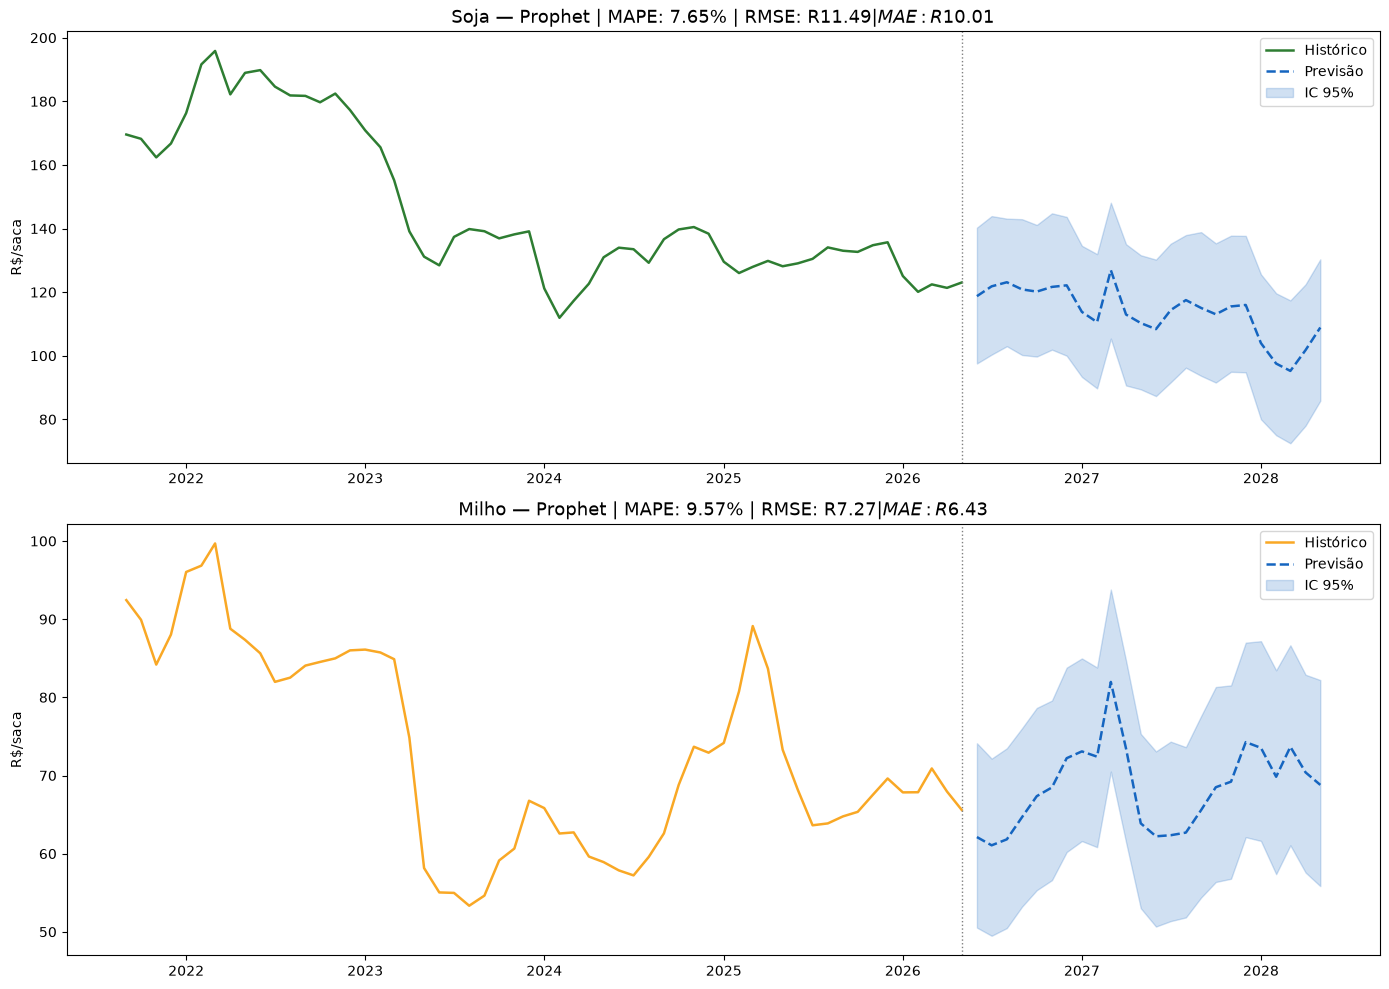

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    r  = resultados[commodity]
    df_h = r['df']
    fc   = r['forecast']
    metr = r['metricas']

    ax.plot(df_h['ds'], df_h['y'], color=cor, linewidth=1.8, label='Histórico')

    fc_future = fc[fc['ds'] > df_h['ds'].max()]
    ax.plot(fc_future['ds'], fc_future['yhat'], color='#1565c0', linewidth=1.8, linestyle='--', label='Previsão')
    ax.fill_between(
        fc_future['ds'],
        fc_future['yhat_lower'],
        fc_future['yhat_upper'],
        alpha=0.2, color='#1565c0', label='IC 95%'
    )
    ax.axvline(df_h['ds'].max(), color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{commodity.capitalize()} — Prophet | MAPE: {metr["MAPE"]}% | RMSE: R${metr["RMSE"]} | MAE: R${metr["MAE"]}')
    ax.set_ylabel('R$/saca')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'prophet_previsao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Performance no período de teste

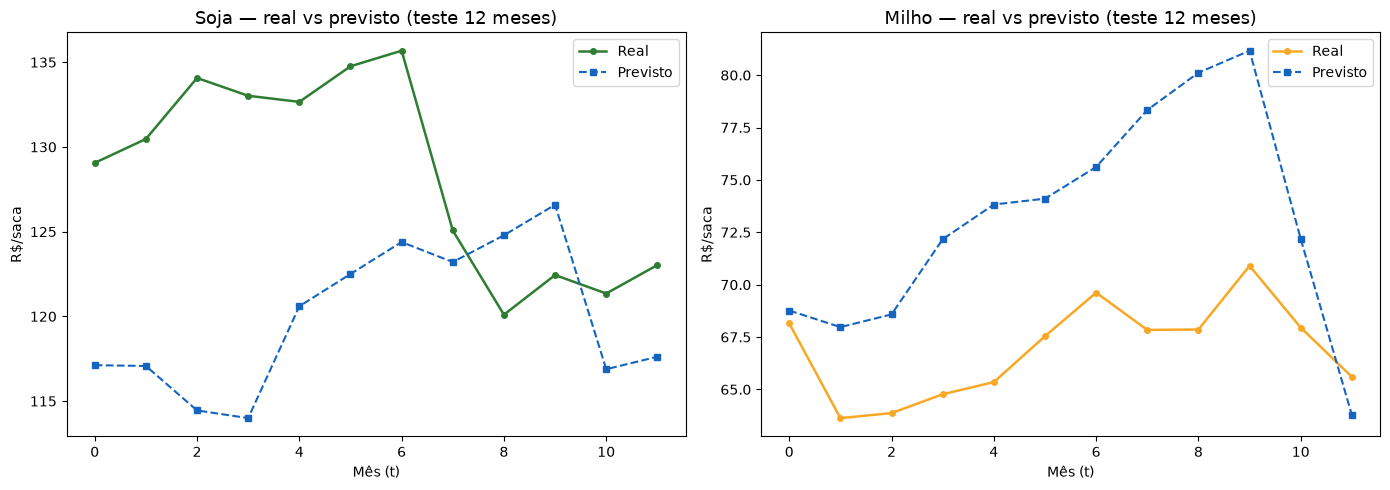

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    r = resultados[commodity]
    n = len(r['y_true'])
    idx = range(n)

    ax.plot(idx, r['y_true'], color=cor,       linewidth=1.8, marker='o', markersize=4, label='Real')
    ax.plot(idx, r['y_pred'], color='#1565c0', linewidth=1.5, marker='s', markersize=4, linestyle='--', label='Previsto')
    ax.set_title(f'{commodity.capitalize()} — real vs previsto (teste 12 meses)')
    ax.set_ylabel('R$/saca')
    ax.set_xlabel('Mês (t)')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'prophet_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretação dos resultados de teste

MAPE de 7-9% é aceitável para preço de commodity com alta volatilidade.
O Prophet erra o timing dos movimentos de curto prazo mas captura bem o nível
e a tendência. O intervalo de confiança crescente no horizonte de 24 meses
reflete corretamente a incerteza da série — não é falha do modelo.

O notebook 05 testa Random Forest com os lags do feature engineering (notebook 03),
o que tende a reduzir o erro de curto prazo. A comparação entre os dois modelos
está na seção de métricas do notebook 05.

---
## 5. Componentes da previsão

In [ ]:
for commodity in ['soja', 'milho']:
    r = resultados[commodity]
    fig = r['modelo'].plot_components(r['forecast'])
    fig.suptitle(f'{commodity.capitalize()} — componentes Prophet', fontsize=12)
    fig.savefig(FIG_DIR / f'prophet_componentes_{commodity}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Resumo de métricas

In [ ]:
print('Métricas — walk-forward validation (12 meses, horizonte 1 mês)\n')
print(f'{"Commodity":<10} {"MAPE":>8} {"RMSE":>10} {"MAE":>10}')
print('-' * 42)
for commodity in ['soja', 'milho']:
    m = resultados[commodity]['metricas']
    print(f'{commodity:<10} {m["MAPE"]:>7.2f}% {"R$" + str(m["RMSE"]):>10} {"R$" + str(m["MAE"]):>10}')

print('\nFiguras salvas em reports/figures/')
print('\nProximo passo: 05_modelo_sklearn.ipynb')